# 1.데이터 전처리

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# CSV 파일 경로 설정
file_path = '/content/drive/MyDrive/2024_하계_알파테스터/전처리/output2.csv'

# CSV 파일 읽어오기 (인코딩 설정)
try:
    df = pd.read_csv(file_path, encoding='utf-8')
    print("File read successfully with utf-8 encoding.")
except UnicodeDecodeError:
    print("utf-8 encoding failed, trying euc-kr encoding.")
    try:
        df = pd.read_csv(file_path, encoding='euc-kr')
        print("File read successfully with euc-kr encoding.")
    except UnicodeDecodeError:
        print("euc-kr encoding failed, trying cp949 encoding.")
        try:
            df = pd.read_csv(file_path, encoding='cp949')
            print("File read successfully with cp949 encoding.")
        except UnicodeDecodeError:
            print("cp949 encoding failed. Please check the file encoding.")

# 데이터프레임 확인
df.head()

File read successfully with utf-8 encoding.


,시도,시군구,노인인구수,여성노인인구수,치매환자수,치매환자유병률,중증 환자,경도인지장애 환자수,경도인지장애 환자유병률,독거노인가구비율,기초연금_수급권자수,치매전담형 장기요양기관 수,치매전담형 장기요양기관 정원,치매전담형 장기요양기관 종사자수,치매안심병원 유무,시설 수,정원,종사자 수,평균 연령
0,서울특별시,서울_종로구,27661.5,15238.5,3127.29,11.31,484.73,6419.92,23.21,8.5,14447.0,1,20,7,0,102,458,496,74.767193
1,서울특별시,서울_중구,24713.5,13792.0,2662.26,10.77,412.65,5671.50,22.95,9.7,14734.0,1,16,4,0,85,528,490,74.545779
2,서울특별시,서울_용산구,38033.0,21471.5,4249.27,11.17,658.64,8782.64,23.09,7.3,16099.0,0,0,0,0,136,456,337,74.682484
3,서울특별시,서울_성동구,47964.0,26850.5,4889.99,10.20,757.95,10951.29,22.83,7.0,24162.0,5,85,43,0,228,816,757,74.167316
4,서울특별시,서울_광진구,54690.5,30211.0,5323.19,9.73,825.09,12342.12,22.57,6.3,28780.0,0,0,0,0,172,1865,925,73.892970


In [ ]:
df[df['시군구'] == '경남_사천시']

,시도,시군구,노인인구수,여성노인인구수,치매환자수,치매환자유병률,중증 환자,경도인지장애 환자수,경도인지장애 환자유병률,독거노인가구비율,기초연금_수급권자수,치매전담형 장기요양기관 수,치매전담형 장기요양기관 정원,치매전담형 장기요양기관 종사자수,치매안심병원 유무,시설 수,정원,종사자 수,평균 연령
209,경상남도,경남_사천시,26684.5,15636.0,3049.31,11.43,472.64,6230.58,23.35,13.8,21058.0,4,74,29,1,429,1541,984,74.942502


In [ ]:
df.loc[df['시군구'] == '경기_남양주시', '치매안심병원 유무'] = 1
df.loc[df['시군구'] == '경남_사천시', '치매안심병원 유무'] = 1
df.to_csv('output.csv', index=False)

In [ ]:
# 결측치 확인
print(df.isnull().sum())

시도                   0
시군구                  0
노인인구수                0
여성노인인구수              0
치매환자수                0
치매환자유병률              0
중증 환자                0
경도인지장애 환자수           0
경도인지장애 환자유병률         0
독거노인가구비율             0
기초연금_수급권자수           0
치매전담형 장기요양기관 수       0
치매전담형 장기요양기관 정원      0
치매전담형 장기요양기관 종사자수    0
치매안심병원 유무            0
시설 수                 0
정원                   0
종사자 수                0
평균 연령                0
dtype: int64


In [ ]:
# 결측치 처리
df['독거노인가구비율'].fillna(df['독거노인가구비율'].mean(), inplace=True)
df['기초연금_수급권자수'].fillna(df['기초연금_수급권자수'].mean(), inplace=True)

In [ ]:
#정규화

# '시도'와 '시군구' 열을 따로 저장
location_columns = ['시도', '시군구']
location_data = df[location_columns]
df_numeric = df.drop(columns=location_columns)

# 정규화
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# 정규화된 데이터와 '시도'와 '시군구' 열을 다시 결합
df_scaled = pd.concat([location_data.reset_index(drop=True), df_numeric_scaled.reset_index(drop=True)], axis=1)

# 결과 확인
print(df_scaled.head())

      시도     시군구     노인인구수   여성노인인구수     치매환자수   치매환자유병률     중증 환자  \
0  서울특별시  서울_종로구 -0.222017 -0.226664 -0.212848  0.189657 -0.212848   
1  서울특별시   서울_중구 -0.241228 -0.243660 -0.242123 -0.174962 -0.242124   
2  서울특별시  서울_용산구 -0.154430 -0.153430 -0.142216  0.095126 -0.142215   
3  서울특별시  서울_성동구 -0.089714 -0.090229 -0.101881 -0.559838 -0.101881   
4  서울특별시  서울_광진구 -0.045880 -0.050745 -0.074610 -0.877192 -0.074612   

   경도인지장애 환자수  경도인지장애 환자유병률  독거노인가구비율  기초연금_수급권자수  치매전담형 장기요양기관 수  \
0   -0.221086      0.133131 -0.746801   -0.707124       -0.452087   
1   -0.242602     -0.211643 -0.541442   -0.689462       -0.452087   
2   -0.153163     -0.025995 -0.952160   -0.605461       -0.839346   
3   -0.090819     -0.370769 -1.003499   -0.109269        1.096950   
4   -0.050835     -0.715543 -1.123292    0.174920       -0.839346   

   치매전담형 장기요양기관 정원  치매전담형 장기요양기관 종사자수  치매안심병원 유무      시설 수        정원  \
0        -0.299619          -0.332099  -0.310835 -1.311096 -0.680703   
1        -0.400868  

# 2.pca

In [ ]:
# 병원이 있는 지역 필터링
X_hospital = df_numeric_scaled[df['치매안심병원 유무'] == 1].values
location_data_hospital = location_data[df['치매안심병원 유무'] == 1]

In [ ]:
df

,시도,시군구,노인인구수,여성노인인구수,치매환자수,치매환자유병률,중증 환자,경도인지장애 환자수,경도인지장애 환자유병률,독거노인가구비율,기초연금_수급권자수,치매전담형 장기요양기관 수,치매전담형 장기요양기관 정원,치매전담형 장기요양기관 종사자수,치매안심병원 유무,시설 수,정원,종사자 수,평균 연령
0,서울특별시,서울_종로구,27661.5,15238.5,3127.29,11.31,484.73,6419.92,23.21,8.5,14447.0,1,20,7,0,102,458,496,74.767193
1,서울특별시,서울_중구,24713.5,13792.0,2662.26,10.77,412.65,5671.50,22.95,9.7,14734.0,1,16,4,0,85,528,490,74.545779
2,서울특별시,서울_용산구,38033.0,21471.5,4249.27,11.17,658.64,8782.64,23.09,7.3,16099.0,0,0,0,0,136,456,337,74.682484
3,서울특별시,서울_성동구,47964.0,26850.5,4889.99,10.20,757.95,10951.29,22.83,7.0,24162.0,5,85,43,0,228,816,757,74.167316
4,서울특별시,서울_광진구,54690.5,30211.0,5323.19,9.73,825.09,12342.12,22.57,6.3,28780.0,0,0,0,0,172,1865,925,73.892970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,경상남도,경남_거창군,18249.5,10798.0,2391.68,13.11,370.71,4396.00,24.09,19.1,14694.0,1,16,0,0,480,593,228,75.893343
223,경상남도,경남_합천군,17754.5,10569.0,2438.95,13.74,378.04,4368.69,24.61,26.9,14929.0,1,25,8,0,554,633,498,76.281665
224,제주특별자치도,제주_제주시,78665.0,44550.5,8700.38,11.06,1348.56,17855.19,22.70,7.4,48763.0,6,88,39,1,460,3345,2418,74.644036
225,제주특별자치도,제주_서귀포시,39036.0,22031.0,4531.17,11.61,702.33,9013.33,23.09,9.6,24915.0,3,48,17,0,206,1388,923,75.012013


In [ ]:
df_hospital = df[df['치매안심병원 유무'] == 1]

df_hospital

,시도,시군구,노인인구수,여성노인인구수,치매환자수,치매환자유병률,중증 환자,경도인지장애 환자수,경도인지장애 환자유병률,독거노인가구비율,기초연금_수급권자수,치매전담형 장기요양기관 수,치매전담형 장기요양기관 정원,치매전담형 장기요양기관 종사자수,치매안심병원 유무,시설 수,정원,종사자 수,평균 연령
11,서울특별시,서울_은평구,90846.5,51757.5,9301.64,10.24,1441.75,20915.97,23.02,8.5,61442.0,4,52,30,1,310,1894,2155,74.228889
55,인천광역시,인천_계양구,84019.5,47320.0,8190.05,9.75,1269.46,18893.02,22.49,7.7,35965.0,4,65,30,1,323,2993,2760,73.553931
56,인천광역시,인천_서구,45206.0,24832.0,4333.18,9.59,671.64,10030.19,22.19,5.4,55801.0,13,223,83,1,471,3440,3241,73.353174
63,광주광역시,광주_광산구,72519.0,41076.5,7287.20,10.05,1129.52,16515.49,22.77,5.8,31132.0,2,24,14,1,579,2694,2518,74.088855
67,대전광역시,대전_유성구,69570.5,38664.5,6697.71,9.63,1038.15,15599.88,22.42,4.7,21194.0,1,25,7,1,285,2180,1482,73.491610
73,울산광역시,울산_울주군,22396.5,12035.5,1906.81,8.51,295.56,4850.29,21.66,8.7,27036.0,1,9,4,1,517,1797,1569,73.679783
78,경기도,경기_부천시,43873.5,24243.0,4201.49,9.58,651.23,9728.53,22.17,7.6,91877.0,11,139,86,1,709,5313,4912,73.384781
86,경기도,경기_남양주시,29969.0,16489.0,2881.63,9.62,446.65,6723.83,22.44,6.8,81773.0,10,167,56,1,999,9427,6130,73.977151
125,충청북도,충북_제천시,46936.5,26327.0,5250.70,11.19,813.86,10893.07,23.21,13.6,24385.0,2,15,12,1,430,1214,1195,74.316855
138,충청남도,충남_서산시,48218.5,27056.0,5309.52,11.01,822.98,11068.55,22.95,9.9,26636.0,3,34,10,1,494,1707,1907,75.235674


/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.10/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.10/dist-packages/seaborn/

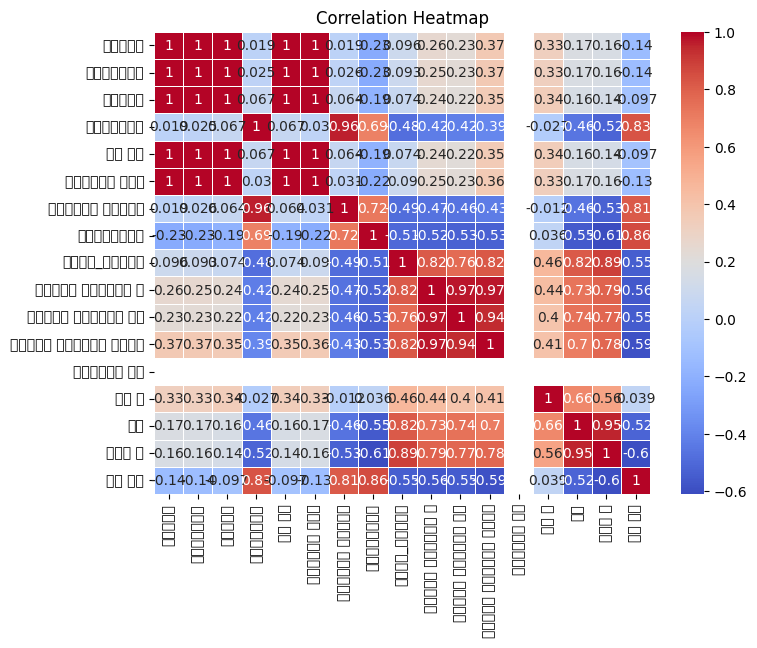

In [ ]:
df_numeric = df_hospital.select_dtypes(include=[float, int])

# 상관관계 행렬 계산
corr_matrix = df_numeric.corr()

# 상관관계 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

<Axes: >

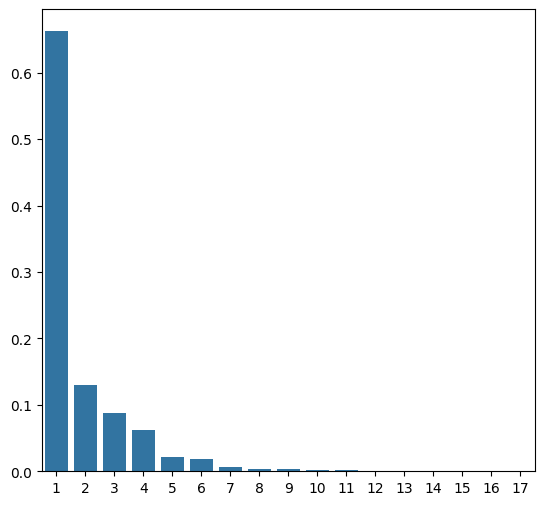

In [ ]:
# PCA 객체 생성 및 적합
pca = PCA()
pca.fit(X_hospital)

# 주성분의 분산 비율 및 누적 분산 비율 계산
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

# 주성분의 분산 비율 히스토그램
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=np.arange(1, len(explained_variance_ratio) + 1), y=explained_variance_ratio)

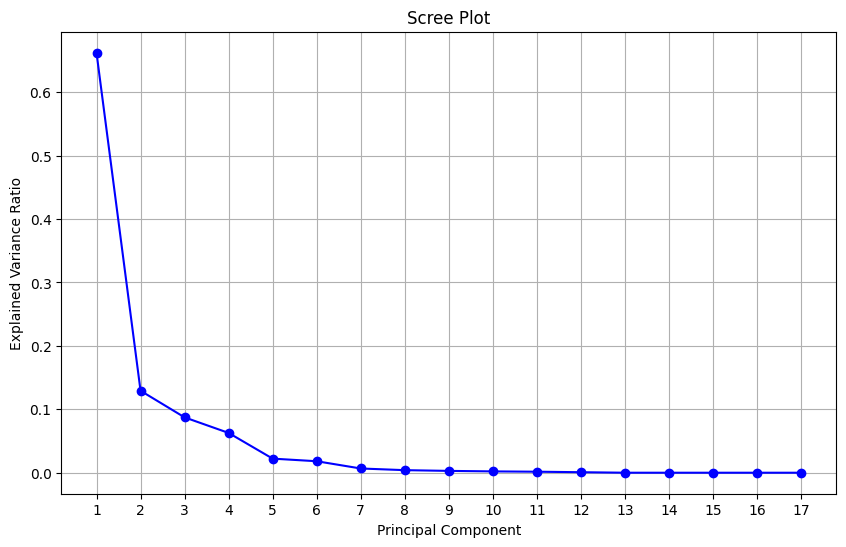

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

In [ ]:
explained_variance_ratio

array([6.62237644e-01, 1.29259293e-01, 8.72997811e-02, 6.27462400e-02,
       2.22210079e-02, 1.81201321e-02, 6.67561476e-03, 4.04584959e-03,
       2.89128268e-03, 2.09320173e-03, 1.59446166e-03, 8.06281299e-04,
       9.02996922e-06, 1.21034066e-07, 5.94007516e-08, 8.95081658e-16,
       1.22544056e-32])

In [ ]:
# PCA 객체 생성 (주성분 개수 10으로 설정)
n_components = 4
pca = PCA(n_components=n_components)
pca.fit(X_hospital)

# PCA 결과 DataFrame 생성
principal_components_hospital = pca.transform(X_hospital)
pca_df_hospital = pd.DataFrame(data=principal_components_hospital, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df_hospital = pd.concat([location_data_hospital.reset_index(drop=True), pca_df_hospital.reset_index(drop=True)], axis=1)

# PCA 결과 확인
explained_variance_ratio = pca.explained_variance_ratio_
components = pca.components_

# 각 주성분의 원래 특성 기여도 확인
feature_names = df_numeric_scaled.columns
for i, component in enumerate(components):
    print(f"PC{i+1} 주요 특성:")
    component_contributions = zip(feature_names, component)
    sorted_contributions = sorted(component_contributions, key=lambda x: abs(x[1]), reverse=True)
    for feature, contribution in sorted_contributions:  # 상위 5개 특성만 표시
        print(f"{feature}: {contribution}")
    print("\n")

PC1 주요 특성:
치매전담형 장기요양기관 종사자수: 0.4602583439794416
치매전담형 장기요양기관 수: 0.43213331456571097
치매전담형 장기요양기관 정원: 0.4316037686561332
기초연금_수급권자수: 0.3363017102497023
정원: 0.30818094830379084
종사자 수: 0.2771710453756956
평균 연령: -0.17912133961471374
경도인지장애 환자유병률: -0.1677584989376463
치매환자유병률: -0.1576243611975757
독거노인가구비율: -0.1386206012693022
시설 수: 0.11781063554559408
치매환자수: 0.050314516085277115
중증 환자: 0.05031444588863568
여성노인인구수: 0.048618254453277596
경도인지장애 환자수: 0.048413347631769674
노인인구수: 0.04800636588622377
치매안심병원 유무: -5.5160313551741e-33


PC2 주요 특성:
치매환자유병률: 0.4199108542413315
경도인지장애 환자유병률: 0.414887515559413
치매환자수: 0.31714210844283713
중증 환자: 0.3171418651554869
평균 연령: 0.27994634673312047
경도인지장애 환자수: 0.2762695634389627
여성노인인구수: 0.27297517852450287
노인인구수: 0.263833371168504
시설 수: 0.2295669009835523
치매전담형 장기요양기관 종사자수: 0.19467519660569002
독거노인가구비율: 0.17302954879034402
치매전담형 장기요양기관 수: 0.10167973536886982
기초연금_수급권자수: -0.08581617797788176
치매전담형 장기요양기관 정원: 0.08566485662557673
종사자 수: -0.06871545961538164
정원: -0.0

In [ ]:
pca_df_hospital['시군구'].unique()

array(['서울_은평구', '인천_계양구', '인천_서구', '광주_광산구', '대전_유성구', '울산_울주군',
       '경기_부천시', '경기_남양주시', '충북_제천시', '충남_서산시', '충남_홍성군', '전북_전주시',
       '전북_군산시', '전남_화순군', '경북_김천시', '경북_안동시', '경북_상주시', '경북_경산시',
       '경남_사천시', '제주_제주시'], dtype=object)

In [ ]:
# 병원이 없는 지역 데이터 준비
X_no_hospital = df_numeric_scaled[df['치매안심병원 유무'] == 0].values
location_data_no_hospital = location_data[df['치매안심병원 유무'] == 0]

# 병원이 없는 지역의 주성분 점수 계산
principal_components_no_hospital = pca.transform(X_no_hospital)

# 병원이 없는 지역 DataFrame 생성
pca_df_no_hospital = pd.DataFrame(data=principal_components_no_hospital, columns=[f'PC{i+1}' for i in range(n_components)])
pca_df_no_hospital = pd.concat([location_data_no_hospital.reset_index(drop=True), pca_df_no_hospital.reset_index(drop=True)], axis=1)

# 주성분에 대한 가중치 설정 (설명 분산 비율 사용)
weights = [0.66, 0.13, 0.09, 0.06]  # 각 주성분의 설명 비율을 가중치로 설정

# 종합 점수 계산
pca_df_no_hospital['Composite_Score'] = np.dot(pca_df_no_hospital[[f'PC{i+1}' for i in range(n_components)]].values, weights)


In [ ]:
pca_df_no_hospital.head()

,시도,시군구,PC1,PC2,PC3,PC4,Composite_Score
0,서울특별시,서울_종로구,-3.182745,-0.782688,0.769900,1.384535,-2.049998
1,서울특별시,서울_중구,-3.176151,-1.210318,1.000609,1.276572,-2.086952
2,서울특별시,서울_용산구,-3.639712,-0.978142,1.107457,0.860345,-2.378077
3,서울특별시,서울_성동구,-0.025209,-0.575516,0.996313,2.379778,0.141000
4,서울특별시,서울_광진구,-2.496775,-1.907672,1.709932,-0.124268,-1.749431


In [ ]:
pca_df_no_hospital['시군구'].unique()

array(['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구',
       '도봉구', '노원구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구',
       '동작구', '관악구', '서초구', '강남구', '송파구', '강동구', '서구', '동구', '영도구',
       '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '연제구', '수영구',
       '사상구', '기장군', '수성구', '달서구', '달성군', '미추홀구', '연수구', '남동구', '부평구',
       '강화군', '옹진군', '대덕구', '수원시', '성남시', '의정부시', '안양시', '광명시', '평택시',
       '동두천시', '안산시', '고양시', '과천시', '구리시', '오산시', '시흥시', '군포시', '의왕시',
       '하남시', '용인시', '파주시', '이천시', '안성시', '김포시', '화성시', '광주시', '양주시',
       '포천시', '여주시', '연천군', '가평군', '양평군', '춘천시', '원주시', '강릉시', '동해시',
       '태백시', '속초시', '삼척시', '홍천군', '횡성군', '영월군', '평창군', '정선군', '철원군',
       '화천군', '양구군', '인제군', '고성군', '양양군', '청주시', '충주시', '보은군', '옥천군',
       '영동군', '진천군', '괴산군', '음성군', '단양군', '증평군', '천안시', '공주시', '보령시',
       '아산시', '논산시', '계룡시', '당진시', '금산군', '부여군', '서천군', '청양군', '예산군',
       '태안군', '익산시', '정읍시', '남원시', '김제시', '완주군', '진안군', '무주군', '장수군',
       '임실군', '순창

In [ ]:
pca_df_no_hospital[pca_df_no_hospital['시군구'].str.contains('제주시')]['Composite_Score']


,Composite_Score
205,-1.118924


In [ ]:
sigu_list =pca_df_no_hospital['시군구'].unique()

if '창원시' in sigu_list:
    print("대구시가 목록에 있습니다.")
else:
    print("대구시가 목록에 없습니다.")

대구시가 목록에 없습니다.


In [ ]:
pca_df_hospital

,시도,시군구,PC1,PC2,PC3,PC4
0,서울특별시,서울_은평구,0.373133,-0.456858,0.571921,0.307452
1,인천광역시,인천_계양구,0.637638,-1.084220,1.224206,0.160866
2,인천광역시,인천_서구,6.133049,-0.451586,-0.136171,2.823240
3,광주광역시,광주_광산구,-0.828353,-0.871874,0.937936,-1.015708
4,대전광역시,대전_유성구,-1.598233,-1.756484,1.967953,-0.108914
5,울산광역시,울산_울주군,-1.583576,-2.610695,1.613052,-0.728028
6,경기도,경기_부천시,6.488813,-0.694390,-0.945529,-0.015310
7,경기도,경기_남양주시,6.596739,-0.625500,-2.081768,-2.576915
8,충청북도,충북_제천시,-2.245867,-0.286745,0.338777,0.294692
9,충청남도,충남_서산시,-1.618186,-0.233808,0.033339,-0.054094


In [ ]:
# 상위 10개 지역 선택
top_locations = pca_df_no_hospital.sort_values(by='Composite_Score', ascending=False).head(10)

# 상위 10개 지역 출력
print("Top 10 Locations by Composite Score:")
print(top_locations[['Composite_Score', '시도', '시군구']])

Top 10 Locations by Composite Score:
     Composite_Score     시도     시군구
68          5.807090    경기도  경기_수원시
52          3.138118  인천광역시  인천_남동구
85          3.054638    경기도  경기_파주시
76          2.984359    경기도  경기_고양시
131         2.511607   충청남도  충남_당진시
75          1.999098    경기도  경기_안산시
64          1.755503  울산광역시   울산_중구
84          1.529981    경기도  경기_용인시
46          1.519520  대구광역시  대구_달서구
171         1.453095   경상북도  경북_포항시


In [ ]:
pca_df_no_hospital['시군구'].unique()

array(['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구',
       '도봉구', '노원구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구',
       '동작구', '관악구', '서초구', '강남구', '송파구', '강동구', '서구', '동구', '영도구',
       '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '연제구', '수영구',
       '사상구', '기장군', '수성구', '달서구', '달성군', '미추홀구', '연수구', '남동구', '부평구',
       '강화군', '옹진군', '대덕구', '수원시', '성남시', '의정부시', '안양시', '광명시', '평택시',
       '동두천시', '안산시', '고양시', '과천시', '구리시', '오산시', '시흥시', '군포시', '의왕시',
       '하남시', '용인시', '파주시', '이천시', '안성시', '김포시', '화성시', '광주시', '양주시',
       '포천시', '여주시', '연천군', '가평군', '양평군', '춘천시', '원주시', '강릉시', '동해시',
       '태백시', '속초시', '삼척시', '홍천군', '횡성군', '영월군', '평창군', '정선군', '철원군',
       '화천군', '양구군', '인제군', '고성군', '양양군', '청주시', '충주시', '보은군', '옥천군',
       '영동군', '진천군', '괴산군', '음성군', '단양군', '증평군', '천안시', '공주시', '보령시',
       '아산시', '논산시', '계룡시', '당진시', '금산군', '부여군', '서천군', '청양군', '예산군',
       '태안군', '익산시', '정읍시', '남원시', '김제시', '완주군', '진안군', '무주군', '장수군',
       '임실군', '순창

In [ ]:
df.columns

Index(['시도', '시군구', '노인인구수', '여성노인인구수', '치매환자수', '치매환자유병률', '중증 환자',
       '경도인지장애 환자수', '경도인지장애 환자유병률', '독거노인가구비율', '기초연금_수급권자수',
       '치매전담형 장기요양기관 수', '치매전담형 장기요양기관 정원', '치매전담형 장기요양기관 종사자수', '치매안심병원 유무',
       '시설 수', '정원', '종사자 수', '평균 연령'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

scaler = StandardScaler()
normalized_data = scaler.fit_transform(df.drop(columns=['시도', '시군구']))

In [ ]:
vif_data = pd.DataFrame()
vif_data['feature'] =['노인인구수', '여성노인인구수', '치매환자수', '치매환자유병률', '중증 환자',
       '경도인지장애 환자수', '경도인지장애 환자유병률', '독거노인가구비율', '기초연금_수급권자수',
       '치매전담형 장기요양기관 수', '치매전담형 장기요양기관 정원', '치매전담형 장기요양기관 종사자수', '치매안심병원 유무',
       '시설 수', '정원', '종사자 수', '평균 연령']
vif_data['VIF'] = [variance_inflation_factor(normalized_data, i) for i in range(normalized_data.shape[1])]

print(vif_data.sort_values('VIF', ascending= False))

              feature           VIF
2               치매환자수  8.331514e+11
4               중증 환자  8.331514e+11
5          경도인지장애 환자수  1.839126e+05
0               노인인구수  6.447729e+04
1             여성노인인구수  4.285100e+04
3             치매환자유병률  2.595408e+01
6        경도인지장애 환자유병률  2.153793e+01
9      치매전담형 장기요양기관 수  2.018906e+01
10    치매전담형 장기요양기관 정원  1.506126e+01
11  치매전담형 장기요양기관 종사자수  9.430401e+00
16              평균 연령  7.532836e+00
14                 정원  5.332140e+00
7            독거노인가구비율  4.893148e+00
15              종사자 수  3.425353e+00
8          기초연금_수급권자수  3.052421e+00
13               시설 수  3.044086e+00
12          치매안심병원 유무  1.175188e+00


# 시각화

In [ ]:
pca_df_no_hospital['시군구'] = pca_df_no_hospital['시군구'].apply(lambda x: x.split('_')[1] if '_' in x else x)

In [ ]:
nan_regions = gdf[gdf['Composite_Score'].isna()]['Region']

print(nan_regions)

16      은평구
94      군위군
111     계양구
136     광산구
153     유성구
175     울주군
187     부천시
198    남양주시
224     제천시
238     서산시
246     홍성군
249     전주시
250     전주시
251     군산시
274     화순군
289     김천시
290     안동시
294     상주시
296     경산시
309     창원시
310     창원시
311     창원시
312     창원시
313     창원시
316     사천시
332     제주시
Name: Region, dtype: object


In [ ]:
gdf

,SIG_CD,SIG_ENG_NM,SIG_KOR_NM,geometry
0,11110,Jongno-gu,종로구,"POLYGON ((127.01462 37.58210, 127.01395 37.581..."
1,11140,Jung-gu,중구,"POLYGON ((127.02620 37.57245, 127.02575 37.572..."
2,11170,Yongsan-gu,용산구,"POLYGON ((126.97201 37.55619, 126.96984 37.555..."
3,11200,Seongdong-gu,성동구,"POLYGON ((127.07522 37.56049, 127.07480 37.560..."
4,11215,Gwangjin-gu,광진구,"POLYGON ((127.08107 37.57242, 127.08104 37.572..."
...,...,...,...,...
245,51790,Hwacheon-gun,화천군,"POLYGON ((127.82530 38.28767, 127.82391 38.288..."
246,51800,Yanggu-gun,양구군,"MULTIPOLYGON (((128.03345 38.29189, 128.03337 ..."
247,51810,Inje-gun,인제군,"POLYGON ((128.27155 38.37724, 128.27106 38.377..."
248,51820,Goseong-gun,고성군,"MULTIPOLYGON (((128.55183 38.30257, 128.55225 ..."


In [ ]:
gdf['SIG_KOR_NM'].unique()

array(['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구',
       '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구',
       '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구', '서구', '동구',
       '영도구', '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '연제구',
       '수영구', '사상구', '기장군', '수성구', '달서구', '달성군', '군위군', '미추홀구', '연수구',
       '남동구', '부평구', '계양구', '강화군', '옹진군', '광산구', '유성구', '대덕구', '울주군',
       '세종특별자치시', '수원시 장안구', '수원시 권선구', '수원시 팔달구', '수원시 영통구', '성남시 수정구',
       '성남시 중원구', '성남시 분당구', '의정부시', '안양시 만안구', '안양시 동안구', '부천시', '광명시',
       '평택시', '동두천시', '안산시 상록구', '안산시 단원구', '고양시 덕양구', '고양시 일산동구',
       '고양시 일산서구', '과천시', '구리시', '남양주시', '오산시', '시흥시', '군포시', '의왕시',
       '하남시', '용인시 처인구', '용인시 기흥구', '용인시 수지구', '파주시', '이천시', '안성시', '김포시',
       '화성시', '광주시', '양주시', '포천시', '여주시', '연천군', '가평군', '양평군', '청주시 상당구',
       '청주시 서원구', '청주시 흥덕구', '청주시 청원구', '충주시', '제천시', '보은군', '옥천군', '영동군',
       '증평군', '진천군', '괴산군', '음성군', '단양군', '천안시 동남구', '천안시 서북구', '공주시',
  


Composite_Score 상위 15개 시군구:
    SIG_KOR_NM  Composite_Score
177    수원시 장안구         5.807090
178    수원시 권선구         5.807090
179    수원시 팔달구         5.807090
180    수원시 영통구         5.807090
109        남동구         3.138118
207        파주시         3.054638
193    고양시 덕양구         2.984359
194   고양시 일산동구         2.984359
195   고양시 일산서구         2.984359
241        당진시         2.511607
191    안산시 상록구         1.999098
192    안산시 단원구         1.999098
6           중구         1.755503
36          중구         1.755503
72          중구         1.755503


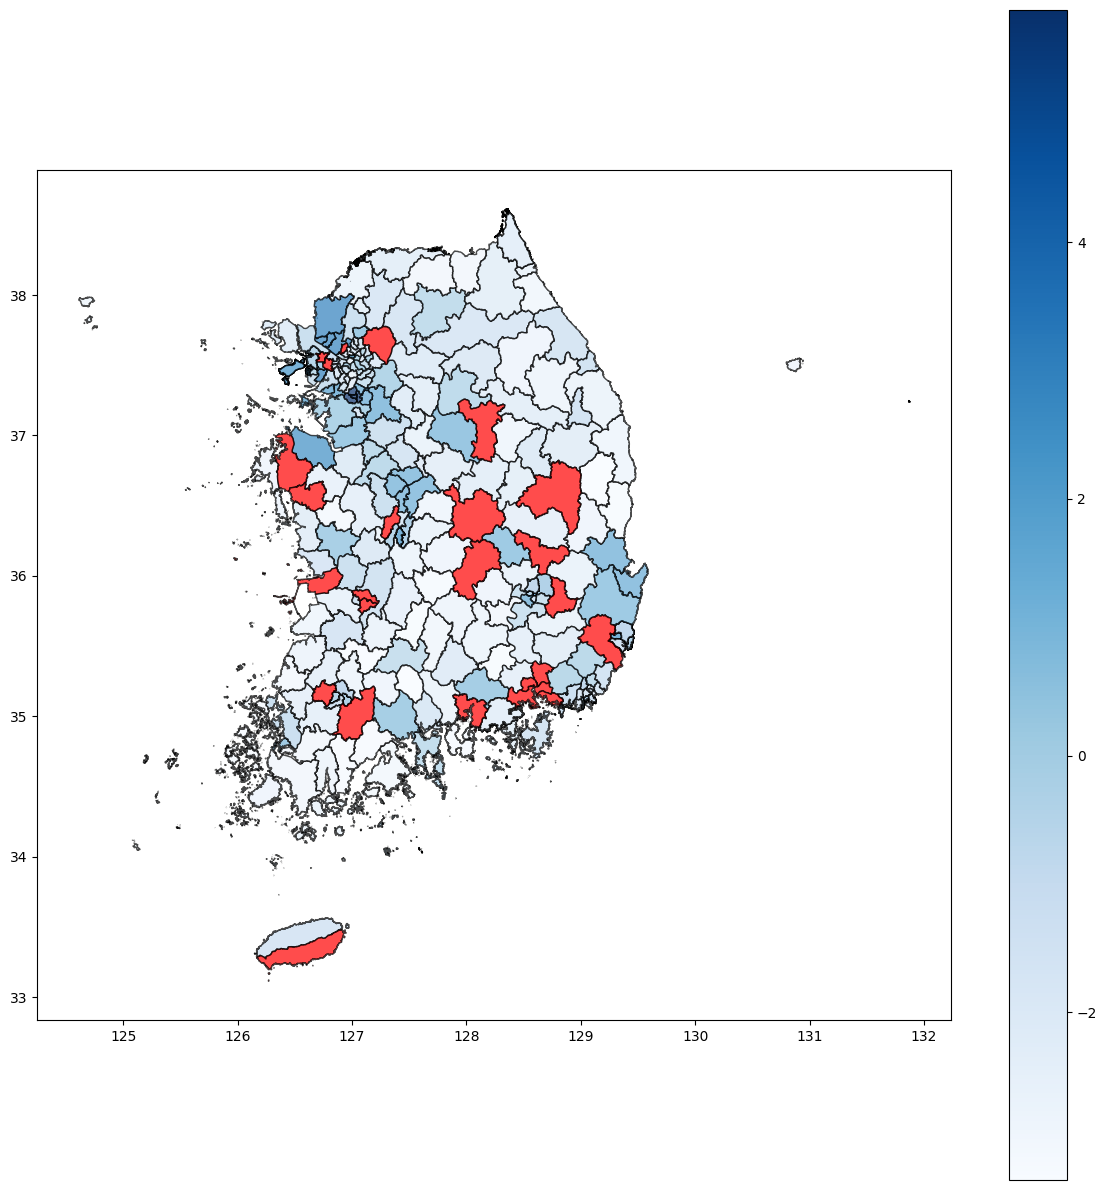

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 예제 데이터 읽기
gdf = gpd.read_file('/content/drive/MyDrive/sig.json')

# 좌표계 설정 (예: WGS84)
gdf.set_crs(epsg=4326, inplace=True)

# 지역명을 통합하는 함수 정의
def unify_region(region_name):
    # 통합할 지역 리스트
    regions_to_unify = [
        '수원시', '고양시', '성남시', '안양시', '안산시', '용인시',
        '천안시', '청주시', '전주시', '포항시', '창원시', '세종'
    ]
    for region in regions_to_unify:
        if region in region_name:
            return region
    return region_name.split('_')[0]  # 기본적인 지역명 반환


pca_df_no_hospital['시군구'] = pca_df_no_hospital['시군구'].replace({

    '세종': '세종특별자치시'
})

# gdf와 pca_df_no_hospital의 지역명을 통합
gdf['Region'] = gdf['SIG_KOR_NM'].apply(unify_region)
pca_df_no_hospital['Region'] = pca_df_no_hospital['시군구'].apply(unify_region)

# pca_df_no_hospital에서 지역별 Composite_Score 데이터프레임 생성
region_scores = pca_df_no_hospital[['Region', 'Composite_Score']].drop_duplicates()

# 지역별 점수를 gdf에 추가
gdf = gdf.merge(region_scores, on='Region', how='left')

# 상위 15개 Composite_Score가 높은 시군구 추출
top_15 = gdf.nlargest(15, 'Composite_Score')[['SIG_KOR_NM', 'Composite_Score']]

print("\nComposite_Score 상위 15개 시군구:")
print(top_15)

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

# Composite_Score 값을 기준으로 색상 맵핑
gdf['color'] = gdf['Composite_Score'].apply(lambda x: 'red' if pd.isna(x) else 'Blues')

# 'NaN' 값을 가진 지역은 빨간색으로, 나머지는 파란색 계열로 표시
gdf[gdf['Composite_Score'].notna()].plot(ax=ax, column='Composite_Score', cmap='Blues', legend=True, edgecolor='black', alpha=0.7)
gdf[gdf['Composite_Score'].isna()].plot(ax=ax, color='red', edgecolor='black', alpha=0.7)

# 레이아웃 자동 조정
plt.tight_layout()

# 시각화 출력
plt.show()
